# Phase 4.7: GC vs PDC vs Combined - Comparison & Significance Testing

**Tujuan:** Menggabungkan skor cross-validation per-fold dari seluruh sub-phase 4.1-4.6
(LDA, SVM, RF, XGBoost, Ensemble, Tuned models) menjadi satu tabel perbandingan, lalu
menguji signifikansi statistik perbedaan performa antara GC, PDC (band terbaik), dan
Combined menggunakan paired t-test dan Wilcoxon signed-rank test (dipasangkan per-fold
menggunakan CV split yang identik, `StratifiedGroupKFold(5, random_state=42)`
(grouped per subject_id agar tidak ada trial subjek yang sama bocor ke train & test), di
semua sub-phase).

**Output:** `output/master_comparison_table.csv`, `output/significance_tests.csv`
**Figures:** `figures/gc_vs_pdc_comparison_heatmap.png`, `figures/gc_vs_pdc_significance_bar.png`


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

PHASE4_DIR = r"D:\Skripsi\new_data\phase_4_classification"
OUTPUT_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.7_gc_vs_pdc_comparison\output"
FIG_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.7_gc_vs_pdc_comparison\figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SUBPHASE_SCORE_FILES = {
    '4.1_lda': 'lda_cv_scores.csv',
    '4.2_svm': 'svm_cv_scores.csv',
    '4.3_random_forest': 'rf_cv_scores.csv',
    '4.4_xgboost': 'xgboost_cv_scores.csv',
    '4.5_ensemble': 'ensemble_cv_scores.csv',
    '4.6_hyperparameter_tuning': 'tuning_cv_scores.csv',
}

frames = []
for subdir, fname in SUBPHASE_SCORE_FILES.items():
    path = os.path.join(PHASE4_DIR, subdir, 'output', fname)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['Source'] = subdir
        frames.append(df)
        print(f"Loaded {len(df):4d} rows from {subdir}/output/{fname}")
    else:
        print(f"MISSING: {path} (run that sub-phase notebook first)")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nTotal per-fold rows: {len(df_all)}")
print(f"Models  : {sorted(df_all['Model'].unique())}")
print(f"Datasets: {sorted(df_all['Dataset'].unique())}")


Loaded   55 rows from 4.1_lda/output/lda_cv_scores.csv
Loaded  165 rows from 4.2_svm/output/svm_cv_scores.csv
Loaded   55 rows from 4.3_random_forest/output/rf_cv_scores.csv
Loaded   55 rows from 4.4_xgboost/output/xgboost_cv_scores.csv
Loaded  165 rows from 4.5_ensemble/output/ensemble_cv_scores.csv
Loaded  165 rows from 4.6_hyperparameter_tuning/output/tuning_cv_scores.csv

Total per-fold rows: 660
Models  : ['LDA', 'RF', 'RF_Tuned', 'SVM_Linear', 'SVM_Poly', 'SVM_RBF', 'SVM_Tuned', 'Stacking', 'Voting_Hard', 'Voting_Soft', 'XGBoost', 'XGBoost_Tuned']
Datasets: ['Combined', 'GC', 'GC+PDC_ROI', 'GC+PDC_ROI+Spectral', 'GC+PDC_Theta+Spectral', 'GC+Spectral', 'GC_ROI', 'PDC_ROI', 'PDC_Theta', 'PDC_Theta+Spectral', 'Spectral']


In [2]:
# Master comparison table: mean/std accuracy & F1 per (Model, Dataset)
master = (
    df_all.groupby(['Model', 'Dataset'])
    .agg(Mean_Accuracy=('Accuracy', 'mean'), Std_Accuracy=('Accuracy', 'std'),
         Mean_F1=('F1_weighted', 'mean'), Std_F1=('F1_weighted', 'std'), N_Folds=('Fold', 'count'))
    .reset_index()
    .sort_values('Mean_Accuracy', ascending=False)
)
master.to_csv(os.path.join(OUTPUT_DIR, 'master_comparison_table.csv'), index=False)
print(master.to_string(index=False))


        Model               Dataset  Mean_Accuracy  Std_Accuracy  Mean_F1   Std_F1  N_Folds
XGBoost_Tuned   GC+PDC_ROI+Spectral       0.755556      0.046849 0.753813 0.049301        5
     Stacking              Combined       0.754074      0.036814 0.753914 0.037725        5
  Voting_Soft   GC+PDC_ROI+Spectral       0.749630      0.060041 0.749001 0.061103        5
    SVM_Tuned   GC+PDC_ROI+Spectral       0.749630      0.046966 0.749705 0.047198        5
     Stacking GC+PDC_Theta+Spectral       0.748148      0.049135 0.747397 0.049714        5
XGBoost_Tuned              Combined       0.745185      0.034980 0.743047 0.036035        5
    SVM_Tuned              Combined       0.742222      0.033702 0.742056 0.035494        5
     Stacking    PDC_Theta+Spectral       0.740741      0.073889 0.740092 0.073457        5
  Voting_Soft              Combined       0.739259      0.042358 0.738527 0.042461        5
XGBoost_Tuned    PDC_Theta+Spectral       0.739259      0.044874 0.736284 0.0473

In [3]:
# Paired significance tests: for each model, compare Accuracy across dataset pairs
# fold-by-fold (same StratifiedGroupKFold(5, random_state=42) split, grouped by
# subject_id, used in every sub-phase notebook, so fold indices are directly comparable
# and no subject leaks across train/test).
sig_rows = []
for model_name, sub in df_all.groupby('Model'):
    ds_present = sub['Dataset'].unique().tolist()
    for i in range(len(ds_present)):
        for j in range(i + 1, len(ds_present)):
            ds_a, ds_b = ds_present[i], ds_present[j]
            a = sub[sub['Dataset'] == ds_a].sort_values('Fold')['Accuracy'].values
            b = sub[sub['Dataset'] == ds_b].sort_values('Fold')['Accuracy'].values
            if len(a) != len(b) or len(a) < 2:
                continue
            diff = a - b
            t_stat, t_p = stats.ttest_rel(a, b)
            if np.all(diff == 0):
                w_stat, w_p = np.nan, 1.0
            else:
                try:
                    w_stat, w_p = stats.wilcoxon(a, b)
                except ValueError:
                    w_stat, w_p = np.nan, np.nan
            sig_rows.append({
                'Model': model_name, 'Dataset_A': ds_a, 'Dataset_B': ds_b,
                'Mean_Acc_A': a.mean(), 'Mean_Acc_B': b.mean(), 'Mean_Diff': diff.mean(),
                'Paired_t_stat': t_stat, 'Paired_t_pvalue': t_p,
                'Wilcoxon_stat': w_stat, 'Wilcoxon_pvalue': w_p,
                'Significant_at_0.05': bool(t_p < 0.05),
            })

df_sig = pd.DataFrame(sig_rows).sort_values('Paired_t_pvalue')
df_sig.to_csv(os.path.join(OUTPUT_DIR, 'significance_tests.csv'), index=False)
print(df_sig.to_string(index=False))


        Model             Dataset_A             Dataset_B  Mean_Acc_A  Mean_Acc_B     Mean_Diff  Paired_t_stat  Paired_t_pvalue  Wilcoxon_stat  Wilcoxon_pvalue  Significant_at_0.05
  Voting_Soft             PDC_Theta              Combined    0.608889    0.739259 -1.303704e-01  -1.290495e+01         0.000208            0.0           0.0625                 True
   SVM_Linear                    GC              Combined    0.468148    0.709630 -2.414815e-01  -1.282630e+01         0.000213            0.0           0.0625                 True
     SVM_Poly                    GC              Combined    0.474074    0.625185 -1.511111e-01  -1.227936e+01         0.000253            0.0           0.0625                 True
      SVM_RBF             PDC_Theta              Combined    0.571852    0.736296 -1.644444e-01  -1.041898e+01         0.000479            0.0           0.0625                 True
     SVM_Poly                    GC           GC+Spectral    0.474074    0.638519 -1.644444e-01

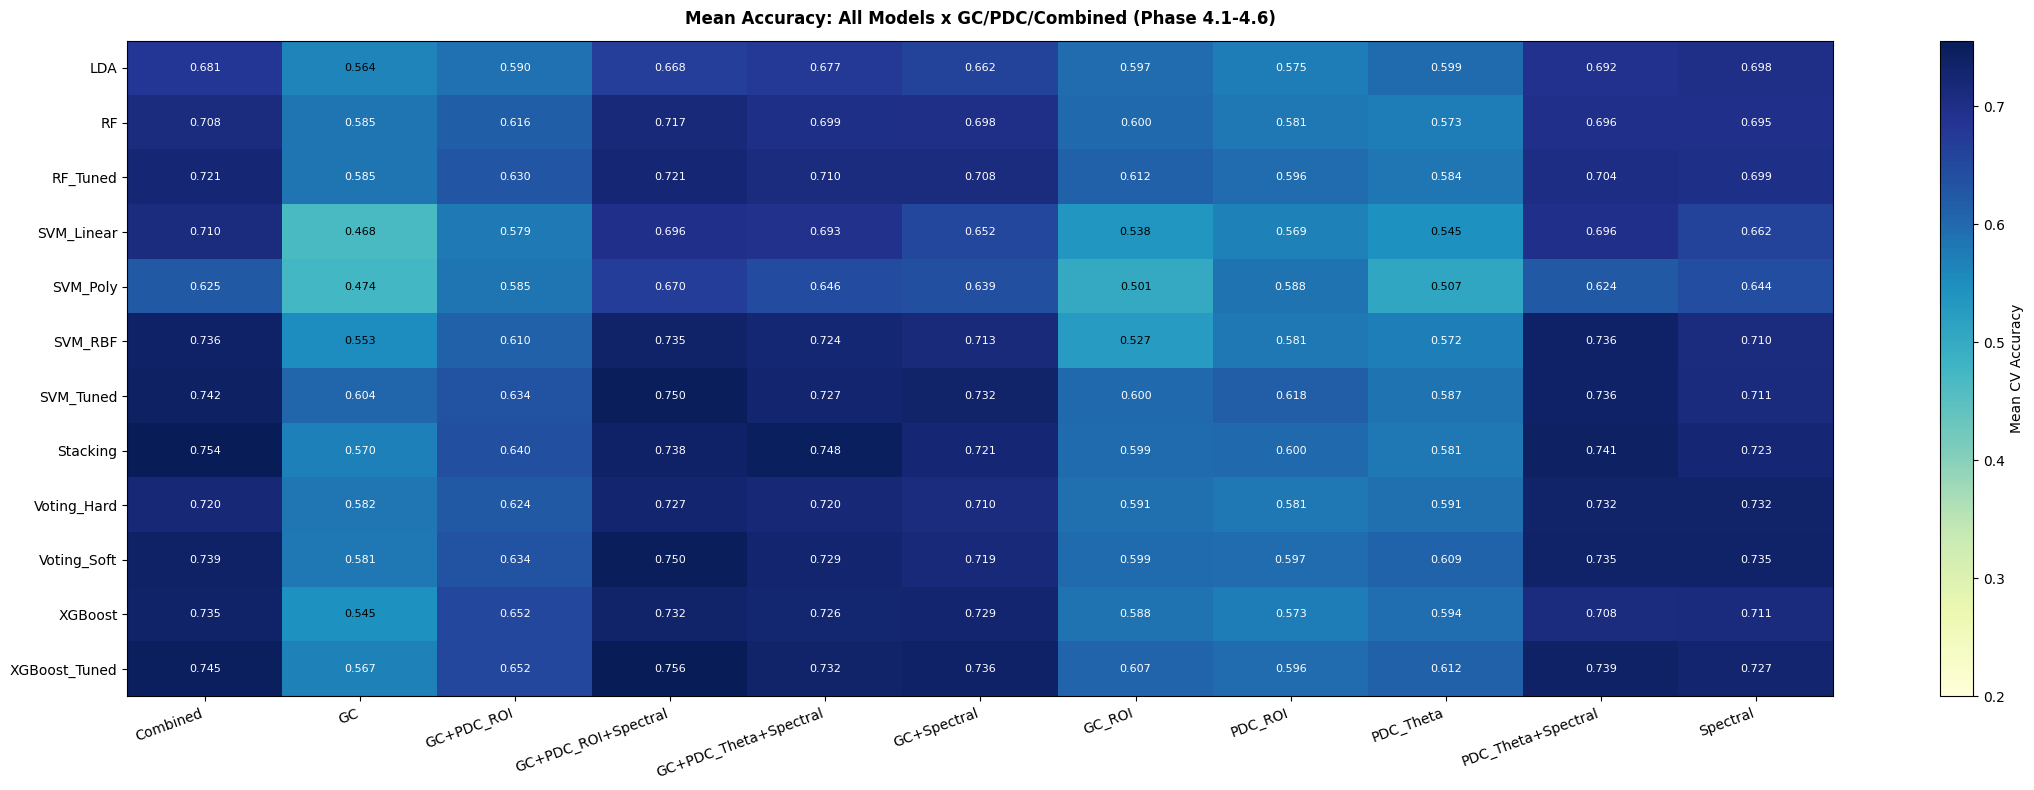

Saved gc_vs_pdc_comparison_heatmap.png


In [4]:
pivot = master.pivot(index='Model', columns='Dataset', values='Mean_Accuracy')
fig, ax = plt.subplots(figsize=(1.8 * len(pivot.columns) + 3, 0.5 * len(pivot.index) + 2))
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto', vmin=0.2, vmax=pivot.values.max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8,
                    color='white' if val > (pivot.values.max() * 0.75) else 'black')
ax.set_title('Mean Accuracy: All Models x GC/PDC/Combined (Phase 4.1-4.6)', fontweight='bold', pad=12)
fig.colorbar(im, ax=ax, label='Mean CV Accuracy')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'gc_vs_pdc_comparison_heatmap.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved gc_vs_pdc_comparison_heatmap.png")


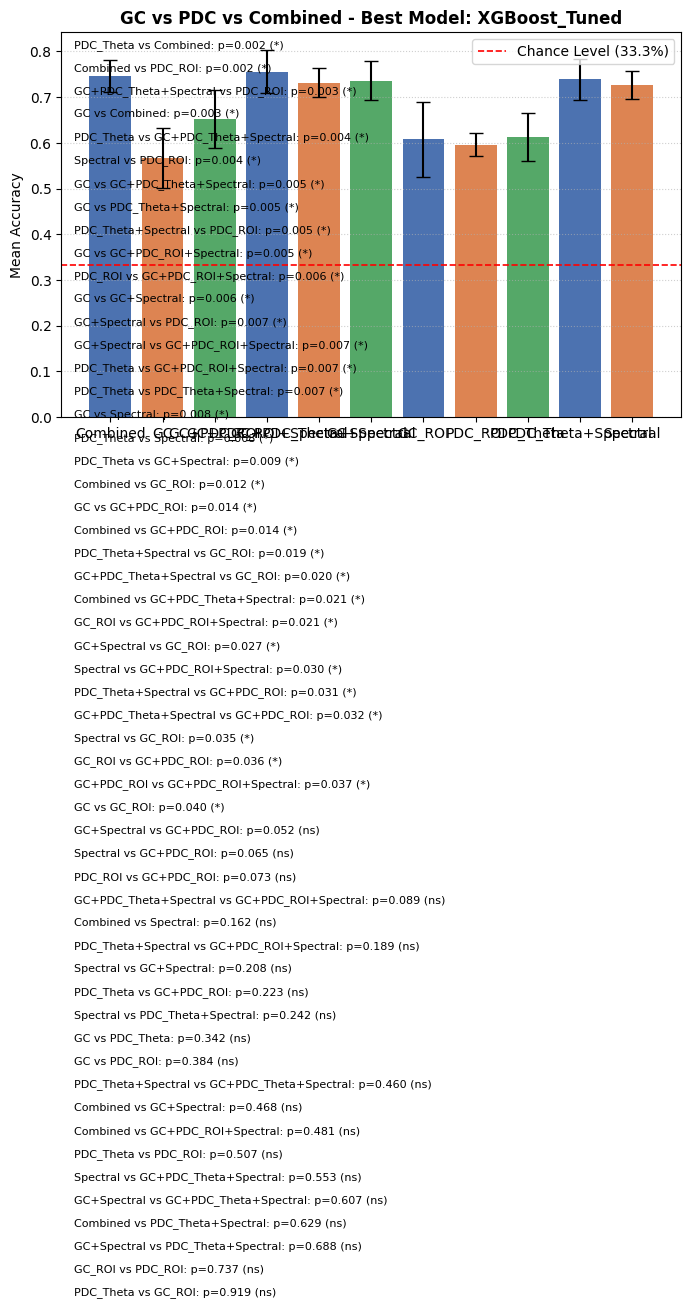

Saved gc_vs_pdc_significance_bar.png


In [5]:
best_model_name = master.iloc[0]['Model']
sub = df_all[df_all['Model'] == best_model_name]
means = sub.groupby('Dataset')['Accuracy'].mean()
stds = sub.groupby('Dataset')['Accuracy'].std()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(means.index, means.values, yerr=stds.values, capsize=5, color=['#4c72b0', '#dd8452', '#55a868'])
ax.axhline(y=1/3, color='red', linestyle='--', linewidth=1.2, label='Chance Level (33.3%)')
ax.set_ylabel('Mean Accuracy')
ax.set_title(f'GC vs PDC vs Combined - Best Model: {best_model_name}', fontweight='bold')
ax.legend()
plt.grid(axis='y', linestyle=':', alpha=0.6)

# Annotate pairwise significance from df_sig for this model
sig_for_model = df_sig[df_sig['Model'] == best_model_name]
y_max = (means + stds).max()
offset = y_max * 0.05
for k, row in enumerate(sig_for_model.itertuples()):
    marker = '*' if row.Paired_t_pvalue < 0.05 else 'ns'
    ax.annotate(f"{row.Dataset_A} vs {row.Dataset_B}: p={row.Paired_t_pvalue:.3f} ({marker})",
                xy=(0.02, 0.98 - 0.06 * k), xycoords='axes fraction', fontsize=8, va='top')

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'gc_vs_pdc_significance_bar.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved gc_vs_pdc_significance_bar.png")


In [6]:
print("="*70)
print("4.7 GC VS PDC COMPARISON COMPLETE")
print("="*70)
print(f"\nOverall best (Model, Dataset): {master.iloc[0]['Model']}, {master.iloc[0]['Dataset']}")
print(f"  Accuracy: {master.iloc[0]['Mean_Accuracy']:.4f} +/- {master.iloc[0]['Std_Accuracy']:.4f}")
print(f"  F1-score: {master.iloc[0]['Mean_F1']:.4f} +/- {master.iloc[0]['Std_F1']:.4f}")

n_sig = df_sig['Significant_at_0.05'].sum()
print(f"\nSignificant pairwise differences (paired t-test, p<0.05): {n_sig} / {len(df_sig)}")

print(f"\nOutputs saved in: {OUTPUT_DIR}")
print(f"Figures saved in: {FIG_DIR}")


4.7 GC VS PDC COMPARISON COMPLETE

Overall best (Model, Dataset): XGBoost_Tuned, GC+PDC_ROI+Spectral
  Accuracy: 0.7556 +/- 0.0468
  F1-score: 0.7538 +/- 0.0493

Significant pairwise differences (paired t-test, p<0.05): 351 / 660

Outputs saved in: D:\Skripsi\new_data\phase_4_classification\4.7_gc_vs_pdc_comparison\output
Figures saved in: D:\Skripsi\new_data\phase_4_classification\4.7_gc_vs_pdc_comparison\figures
